In [5]:
# For this practical example we will need the following libraries and modules
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
import seaborn as sns
sns.set()

In [41]:
# Load the data from a .csv 
raw_data = pd.read_csv('Data/car_data.csv')

# Let's explore the top 5 rows of the df
raw_data.head()

,Brand,Price,Body,Mileage,EngineV,Engine Type,Registration,Year,Model
0,BMW,4200.0,sedan,277,2.0,Petrol,yes,1991,320
1,Mercedes-Benz,7900.0,van,427,2.9,Diesel,yes,1999,Sprinter 212
2,Mercedes-Benz,13300.0,sedan,358,5.0,Gas,yes,2003,S 500
3,Audi,23000.0,crossover,240,4.2,Petrol,yes,2007,Q7
4,Toyota,18300.0,crossover,120,2.0,Petrol,yes,2011,Rav 4


In [7]:
# Descriptive statistics
raw_data.describe(include='all')

,Brand,Price,Body,Mileage,EngineV,Engine Type,Registration,Year,Model
count,4345,4173.000000,4345,4345.000000,4195.000000,4345,4345,4345.000000,4345
unique,7,NaN,6,NaN,NaN,4,2,NaN,312
top,Volkswagen,NaN,sedan,NaN,NaN,Diesel,yes,NaN,E-Class
freq,936,NaN,1649,NaN,NaN,2019,3947,NaN,199
mean,NaN,19418.746935,NaN,161.237284,2.790734,NaN,NaN,2006.550058,NaN
std,NaN,25584.242620,NaN,105.705797,5.066437,NaN,NaN,6.719097,NaN
min,NaN,600.000000,NaN,0.000000,0.600000,NaN,NaN,1969.000000,NaN
25%,NaN,6999.000000,NaN,86.000000,1.800000,NaN,NaN,2003.000000,NaN
50%,NaN,11500.000000,NaN,155.000000,2.200000,NaN,NaN,2008.000000,NaN
75%,NaN,21700.000000,NaN,230.000000,3.000000,NaN,NaN,2012.000000,NaN


In [8]:
# Dealing with missing values
raw_data.isnull().sum()

Brand             0
Price           172
Body              0
Mileage           0
EngineV         150
Engine Type       0
Registration      0
Year              0
Model             0
dtype: int64

In [9]:
# Missing value is just 5%, so removing it.
data_no_mv = raw_data.dropna(axis=0)
data_no_mv.describe(include='all')


,Brand,Price,Body,Mileage,EngineV,Engine Type,Registration,Year,Model
count,4025,4025.000000,4025,4025.000000,4025.000000,4025,4025,4025.000000,4025
unique,7,NaN,6,NaN,NaN,4,2,NaN,306
top,Volkswagen,NaN,sedan,NaN,NaN,Diesel,yes,NaN,E-Class
freq,880,NaN,1534,NaN,NaN,1861,3654,NaN,188
mean,NaN,19552.308065,NaN,163.572174,2.764586,NaN,NaN,2006.379627,NaN
std,NaN,25815.734988,NaN,103.394703,4.935941,NaN,NaN,6.695595,NaN
min,NaN,600.000000,NaN,0.000000,0.600000,NaN,NaN,1969.000000,NaN
25%,NaN,6999.000000,NaN,90.000000,1.800000,NaN,NaN,2003.000000,NaN
50%,NaN,11500.000000,NaN,158.000000,2.200000,NaN,NaN,2007.000000,NaN
75%,NaN,21900.000000,NaN,230.000000,3.000000,NaN,NaN,2012.000000,NaN


In [10]:
duplicate_count = data_no_mv.duplicated().sum()
print("\nNumber of duplicate rows:", duplicate_count)


Number of duplicate rows: 50


In [11]:
if duplicate_count > 0:
    print("\nPreview of duplicate rows:")
    display(data_no_mv[data_no_mv.duplicated()])
else:
    print("\nNo duplicate rows found.")


Preview of duplicate rows:


,Brand,Price,Body,Mileage,EngineV,Engine Type,Registration,Year,Model
348,Mercedes-Benz,199999.0,crossover,0,5.50,Petrol,yes,2016,GLS 63
602,Mercedes-Benz,199999.0,crossover,0,5.50,Petrol,yes,2016,GLS 63
1160,BMW,47000.0,other,5,2.00,Petrol,yes,2014,Z4
1573,Volkswagen,24900.0,sedan,1,1.60,Diesel,yes,2016,Jetta
1929,BMW,75555.0,sedan,30,4.40,Petrol,yes,2014,550
1943,Mercedes-Benz,20400.0,sedan,190,1.80,Gas,yes,2011,E-Class
2008,Mercedes-Benz,47600.0,van,0,2.20,Diesel,yes,2016,Vito
2037,Mitsubishi,15900.0,crossover,180,3.00,Gas,yes,2008,Pajero Wagon
2044,Mercedes-Benz,47600.0,van,0,2.20,Diesel,yes,2016,Vito
2380,Audi,39999.0,crossover,45,2.00,Diesel,yes,2014,Q5


In [12]:
data_no_mv.drop_duplicates(inplace=True)
print("Number of duplicate rows after removing:", data_no_mv.duplicated().sum())

Number of duplicate rows after removing: 0


C:\Users\banne\AppData\Local\Temp\ipykernel_5804\2850482922.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_no_mv.drop_duplicates(inplace=True)


In [13]:
print(data_no_mv.dtypes)

Brand            object
Price           float64
Body             object
Mileage           int64
EngineV         float64
Engine Type      object
Registration     object
Year              int64
Model            object
dtype: object


In [15]:
data_no_mv.describe(include='all')

,Brand,Price,Body,Mileage,EngineV,Engine Type,Registration,Year,Model
count,3975,3975.000000,3975,3975.000000,3975.000000,3975,3975,3975.000000,3975
unique,7,NaN,6,NaN,NaN,4,2,NaN,306
top,Volkswagen,NaN,sedan,NaN,NaN,Diesel,yes,NaN,E-Class
freq,871,NaN,1518,NaN,NaN,1832,3604,NaN,181
mean,NaN,19056.936091,NaN,164.820126,2.763643,NaN,NaN,2006.290063,NaN
std,NaN,24976.141632,NaN,103.117252,4.965189,NaN,NaN,6.683223,NaN
min,NaN,600.000000,NaN,0.000000,0.600000,NaN,NaN,1969.000000,NaN
25%,NaN,6950.000000,NaN,92.000000,1.800000,NaN,NaN,2002.000000,NaN
50%,NaN,11400.000000,NaN,159.000000,2.200000,NaN,NaN,2007.000000,NaN
75%,NaN,21317.500000,NaN,230.000000,3.000000,NaN,NaN,2011.000000,NaN


In [ ]:
### Dealing with outliers with the help of PDF

C:\Users\banne\AppData\Local\Temp\ipykernel_5804\216991009.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data_no_mv['Price'])


<Axes: xlabel='Price', ylabel='Density'>

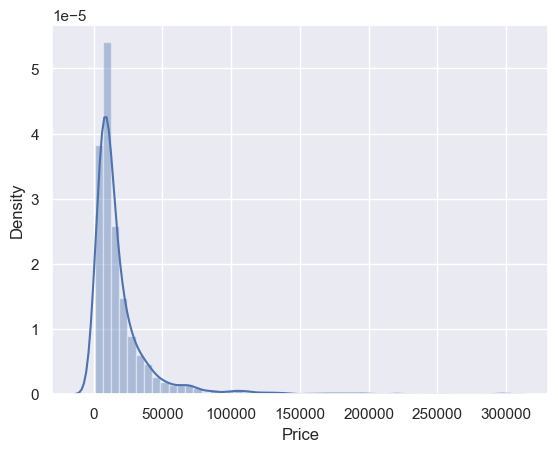

In [17]:
sns.distplot(data_no_mv['Price'])

In [16]:
q = data_no_mv['Price'].quantile(0.99)

data_1 = data_no_mv[data_no_mv['Price']<q]

# we have essentially removed the top 1% of the data about 'Price'

data_1.describe(include='all')

,Brand,Price,Body,Mileage,EngineV,Engine Type,Registration,Year,Model
count,3933,3933.000000,3933,3933.000000,3933.000000,3933,3933,3933.000000,3933
unique,7,NaN,6,NaN,NaN,4,2,NaN,302
top,Volkswagen,NaN,sedan,NaN,NaN,Diesel,yes,NaN,E-Class
freq,871,NaN,1507,NaN,NaN,1821,3562,NaN,181
mean,NaN,17361.081098,NaN,166.424104,2.744266,NaN,NaN,2006.200102,NaN
std,NaN,18162.274471,NaN,102.458875,4.986896,NaN,NaN,6.659452,NaN
min,NaN,600.000000,NaN,0.000000,0.600000,NaN,NaN,1969.000000,NaN
25%,NaN,6900.000000,NaN,95.000000,1.800000,NaN,NaN,2002.000000,NaN
50%,NaN,11200.000000,NaN,160.000000,2.200000,NaN,NaN,2007.000000,NaN
75%,NaN,20900.000000,NaN,230.000000,3.000000,NaN,NaN,2011.000000,NaN


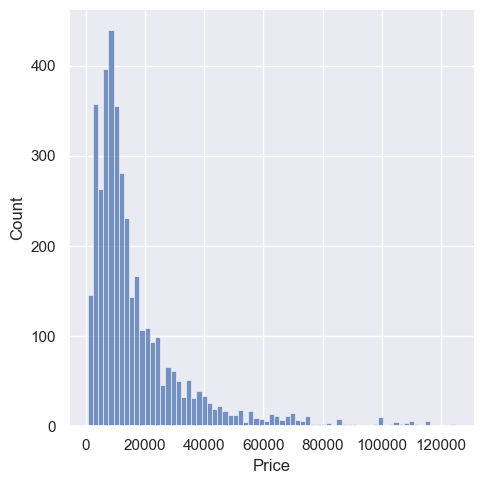

In [19]:
sns.displot(data_1['Price'])

C:\Users\banne\AppData\Local\Temp\ipykernel_5804\4145251247.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data_no_mv['Mileage'])


<Axes: xlabel='Mileage', ylabel='Density'>

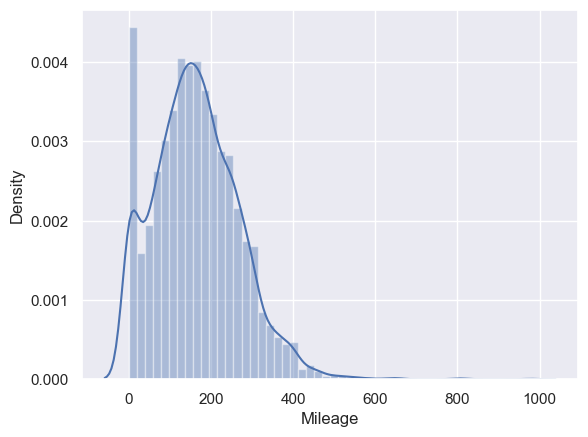

In [20]:
# We can do it with the other numerical variables in a similar way
sns.distplot(data_no_mv['Mileage'])

In [21]:
q = data_1['Mileage'].quantile(0.99)
data_2 = data_1[data_1['Mileage']<q]

C:\Users\banne\AppData\Local\Temp\ipykernel_5804\1950307955.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data_2['Mileage'])


<Axes: xlabel='Mileage', ylabel='Density'>

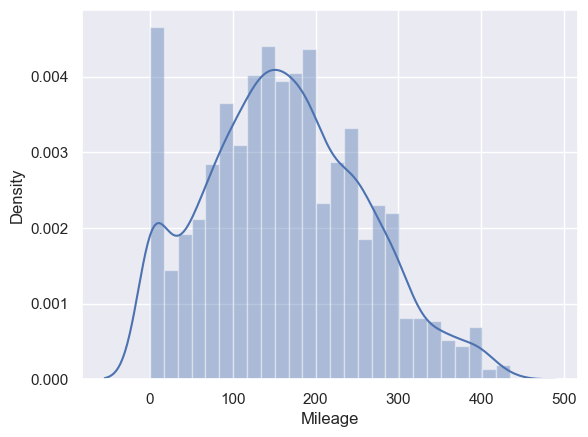

In [22]:
sns.distplot(data_2['Mileage'])

C:\Users\banne\AppData\Local\Temp\ipykernel_5804\823394628.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data_no_mv['EngineV'])


<Axes: xlabel='EngineV', ylabel='Density'>

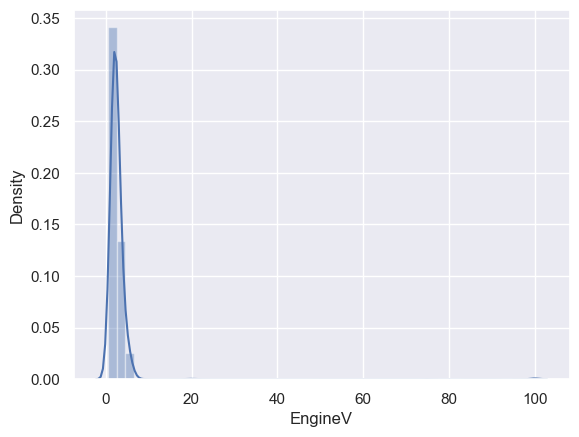

In [23]:
sns.distplot(data_no_mv['EngineV'])

In [24]:
# There's some weired values which need to be check manually.
# Car engine volumes are usually (always?) below 6.5l
data_3 = data_2[data_2['EngineV']<6.5]

C:\Users\banne\AppData\Local\Temp\ipykernel_5804\1902427236.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data_3['EngineV'])


<Axes: xlabel='EngineV', ylabel='Density'>

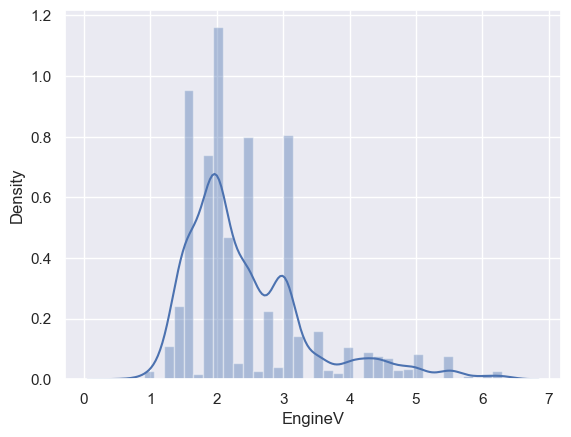

In [25]:
sns.distplot(data_3['EngineV'])

C:\Users\banne\AppData\Local\Temp\ipykernel_5804\534082538.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data_no_mv['Year'])


<Axes: xlabel='Year', ylabel='Density'>

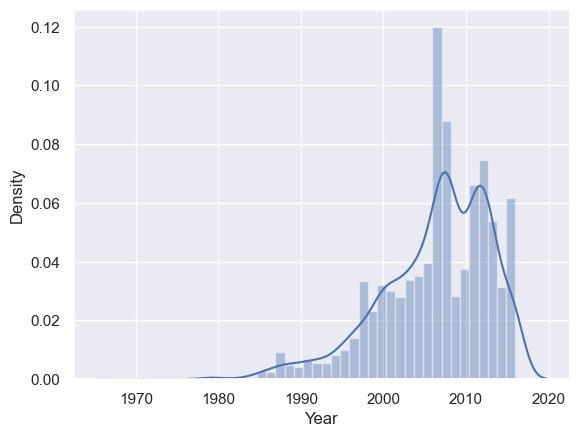

In [27]:
sns.distplot(data_no_mv['Year'])

In [30]:
q = data_3['Year'].quantile(0.01)
data_4 = data_3[data_3['Year']>q]

C:\Users\banne\AppData\Local\Temp\ipykernel_5804\2748958191.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data_4['Year'])


<Axes: xlabel='Year', ylabel='Density'>

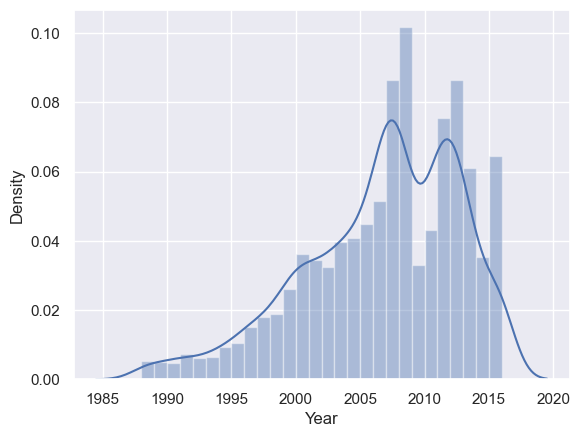

In [32]:
sns.distplot(data_4['Year'])

In [33]:
#we have now messed up indexes. so to arrange it we do:

data_cleaned = data_4.reset_index(drop=True)

In [34]:
data_cleaned.describe(include='all')

,Brand,Price,Body,Mileage,EngineV,Engine Type,Registration,Year,Model
count,3816,3816.000000,3816,3816.000000,3816.000000,3816,3816,3816.000000,3816
unique,7,NaN,6,NaN,NaN,4,2,NaN,291
top,Volkswagen,NaN,sedan,NaN,NaN,Diesel,yes,NaN,E-Class
freq,839,NaN,1446,NaN,NaN,1775,3454,NaN,174
mean,NaN,17708.599610,NaN,161.829140,2.447031,NaN,NaN,2006.619759,NaN
std,NaN,18262.379077,NaN,95.257431,0.948768,NaN,NaN,6.087334,NaN
min,NaN,800.000000,NaN,0.000000,0.600000,NaN,NaN,1988.000000,NaN
25%,NaN,7191.750000,NaN,93.000000,1.800000,NaN,NaN,2003.000000,NaN
50%,NaN,11500.000000,NaN,158.000000,2.200000,NaN,NaN,2008.000000,NaN
75%,NaN,21000.000000,NaN,228.000000,3.000000,NaN,NaN,2011.000000,NaN


In [39]:
print(data_cleaned.isnull().sum())

Brand           0
Price           0
Body            0
Mileage         0
EngineV         0
Engine Type     0
Registration    0
Year            0
Model           0
dtype: int64


In [36]:
data_cleaned.to_csv('Data/cleaned_car_data.csv', index=False)